In [1]:
from api import maniskill, tracking
from api.video import show, draw_tracks
import matplotlib.pyplot as plt
import numpy as np
import torch
from mani_skill.utils import sapien_utils

/home/somatic/faraz/control-proj/control/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Ground-truth point tracking on the StackCube-v1 demo replay. Points sampled in frame 0 are pinned to the
# rigid body under them (segmentation) and carried forward with that body's pose, then projected back into
# base_camera with an occlusion test against the rendered depth (see api/tracking.py).
TASK, CAM = "StackCube-v1", "base_camera"
demo = maniskill.load_demo(TASK)
env = maniskill.make_env(
    TASK, num_envs=1,
    obs_mode=tracking.OBS_MODE,  # rgb + position + segmentation from the sensor cameras
    # base_camera moved from its default (90deg FOV, ~0.7m head-on, where the 4cm cubes are ~18px wide) to a
    # closer 3/4 view that keeps the whole pick-and-place in frame.
    sensor_configs=dict(
        width=512, height=512,
        base_camera=dict(pose=sapien_utils.look_at(eye=[0.4, 0.45, 0.45], target=[-0.07, 0, 0.08]), fov=0.9),
    ),
    control_mode=demo.control_mode,
    max_episode_steps=len(demo.actions) + 1,
)

obs, _ = env.reset(**demo.reset_kwargs)
# uniform 32x32 grid of queries over frame 0 (pixels on nothing are dropped), like a foundation tracker's grid mode
pts = tracking.grid_points(env, obs, CAM, grid_size=32)

frames, uv, xyz, visible = [], [], [], []
def record(obs):
    frames.append(obs["sensor_data"][CAM]["rgb"][0].cpu().numpy())
    for buf, x in zip((uv, xyz, visible), tracking.locate(env, obs, pts)):
        buf.append(x)

record(obs)
for a in demo.actions:
    obs, reward, terminated, truncated, info = env.step(torch.from_numpy(a).unsqueeze(0))
    record(obs)
env.close()
uv, xyz, visible = np.stack(uv), np.stack(xyz), np.stack(visible)  # [T, N, 2], [T, N, 3], [T, N]

names = np.array(pts.body_names)
print("replay success:", info["success"].item(), f"| {len(names)} points, tracks {uv.shape}")
for b in dict.fromkeys(names):
    print(f"  {b:16s} n={(names == b).sum():3d}  visible {visible[:, names == b].mean():.0%}")

replay success: True | 1024 points, tracks (108, 1024, 2)
  ground           n=136  visible 87%
  panda_link6      n= 29  visible 97%
  panda_link5      n= 31  visible 96%
  panda_link1      n= 31  visible 91%
  panda_link2      n= 15  visible 99%
  panda_link7      n= 23  visible 100%
  table-workspace  n=685  visible 97%
  panda_hand       n= 33  visible 94%
  panda_link0      n= 22  visible 97%
  camera_link      n=  6  visible 100%
  panda_rightfinger n=  2  visible 79%
  panda_leftfinger n=  2  visible 100%
  cubeA            n=  3  visible 100%
  cubeB            n=  6  visible 98%


In [3]:
# Colored by initial image row (CoTracker-style rainbow); dots only where visible, with a fading 10-step trail.
colors = (plt.cm.gist_rainbow(uv[0, :, 1] / frames[0].shape[0])[:, :3] * 255).astype(np.uint8)
show(draw_tracks(frames, uv, visible, colors, trail=10, radius=2), fps=env.unwrapped.control_freq, width=512)

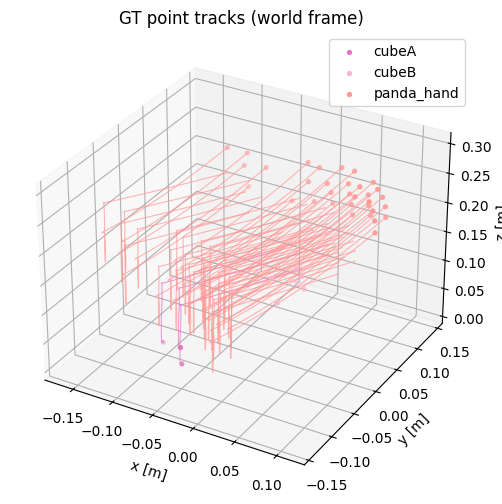

In [4]:
# 3D world-frame tracks for the bodies that move during stacking (the table/base are static).
body_ids = {b: i for i, b in enumerate(dict.fromkeys(names))}
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(projection="3d")
for b in ["cubeA", "cubeB", "panda_hand"]:
    m = names == b
    if not m.any():
        continue
    c = plt.cm.tab20.colors[body_ids[b] % 20]
    for n in np.nonzero(m)[0]:
        ax.plot(*xyz[:, n].T, color=c, lw=0.8, alpha=0.7)
    ax.scatter(*xyz[0, m].T, color=c, s=8, label=b)
ax.set(xlabel="x [m]", ylabel="y [m]", zlabel="z [m]", title="GT point tracks (world frame)")
ax.legend()
plt.show()

In [5]:
# Other tasks: the same grid tracking, via tracking.track_demo (replays the task's demo with a 32x32 grid of
# frame-0 queries). Nothing is task-specific except the camera: each task's default base_camera is either wide and
# far (objects ~10-20px) or blocked by the arm, so it's re-placed per task with eye/target/fov.
from api.video import track_colors

def show_tracks(tr):
    print(f"replay success: {tr.success} | {tr.uv.shape[1]} points x {tr.uv.shape[0]} frames | "
          f"visible {tr.visible.mean():.0%} | bodies: {sorted(set(tr.body_names))}")
    colors = track_colors(tr.uv[0], tr.frames.shape[1])
    return show(draw_tracks(tr.frames, tr.uv, tr.visible, colors, trail=10, radius=2), fps=tr.fps, width=512)

show_tracks(tracking.track_demo("PickCube-v1", eye=[0.45, 0.5, 0.55], target=[-0.05, 0, 0.15], fov=1.0))

replay success: True | 1018 points x 75 frames | visible 93% | bodies: ['cube', 'ground', 'panda_hand', 'panda_link0', 'panda_link1', 'panda_link2', 'panda_link3', 'panda_link5', 'panda_link6', 'panda_link7', 'panda_rightfinger', 'table-workspace']


In [6]:
show_tracks(tracking.track_demo("PlugCharger-v1", eye=[0.4, 0.45, 0.45], target=[-0.07, 0, 0.08], fov=0.9))

replay success: True | 1024 points x 157 frames | visible 87% | bodies: ['camera_link', 'charger', 'ground', 'panda_hand', 'panda_leftfinger', 'panda_link0', 'panda_link1', 'panda_link2', 'panda_link5', 'panda_link6', 'panda_link7', 'panda_rightfinger', 'receptacle', 'table-workspace']


In [7]:
show_tracks(tracking.track_demo("PegInsertionSide-v1", eye=[0.45, -0.45, 0.45], target=[-0.05, 0.05, 0.05], fov=1.0))

replay success: True | 1024 points x 179 frames | visible 89% | bodies: ['box_with_hole_0', 'ground', 'panda_hand', 'panda_link0', 'panda_link1', 'panda_link2', 'panda_link6', 'panda_link7', 'panda_rightfinger', 'peg_0', 'table-workspace']


In [8]:
# StackThree-v1: our custom task (api/maniskill_tasks.py), replaying its committed motion-planning demo
show_tracks(tracking.track_demo("StackThree-v1", eye=[0.4, 0.45, 0.45], target=[-0.07, 0, 0.08], fov=0.9))

replay success: True | 1024 points x 235 frames | visible 92% | bodies: ['camera_link', 'cubeA', 'cubeB', 'cubeC', 'ground', 'panda_hand', 'panda_leftfinger', 'panda_link0', 'panda_link1', 'panda_link2', 'panda_link5', 'panda_link6', 'panda_link7', 'panda_rightfinger', 'table-workspace']
